In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_processed.csv"
)

val_df = pd.read_csv(
    "../data/processed/validation_processed.csv"
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (68976, 3)
Validation: (8878, 3)


In [3]:
X_train = train_df["clean_text"]
y_train = train_df["labels"]

X_val = val_df["clean_text"]
y_val = val_df["labels"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (68976,)
y_train: (68976,)
X_val: (8878,)
y_val: (8878,)


In [4]:
tfidf_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.joblib"
)

print("TF-IDF vectorizer loaded!")

TF-IDF vectorizer loaded!


In [5]:
X_train_tfidf = tfidf_vectorizer.transform(
    X_train
)

X_val_tfidf = tfidf_vectorizer.transform(
    X_val
)

print(
    "Train TF-IDF:",
    X_train_tfidf.shape
)

print(
    "Validation TF-IDF:",
    X_val_tfidf.shape
)

Train TF-IDF: (68976, 100000)
Validation TF-IDF: (8878, 100000)


In [6]:
lr_model = LogisticRegression(
    C=1.0,
    solver="saga",
    max_iter=500,
    random_state=42
)

In [7]:
lr_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed!")

Training completed!


In [9]:
y_val_pred = lr_model.predict(
    X_val_tfidf
)
comparison = pd.DataFrame({
    "Actual": y_val.iloc[:10].values,
    "Predicted": y_val_pred[:10]
})

comparison

,Actual,Predicted
0,nl,nl
1,nl,nl
2,es,es
3,it,it
4,ar,ar
5,ru,ru
6,tr,tr
7,nl,nl
8,fr,fr
9,es,es


In [10]:
accuracy = accuracy_score(
    y_val,
    y_val_pred
)

print(
    f"Accuracy: {accuracy:.4f}"
)

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

Accuracy: 0.9945
Accuracy: 99.45%


In [12]:
precision_macro = precision_score(
    y_val,
    y_val_pred,
    average="macro"
)

recall_macro = recall_score(
    y_val,
    y_val_pred,
    average="macro"
)

f1_macro = f1_score(
    y_val,
    y_val_pred,
    average="macro"
)

precision_weighted = precision_score(
    y_val,
    y_val_pred,
    average="weighted"
)

recall_weighted = recall_score(
    y_val,
    y_val_pred,
    average="weighted"
)

f1_weighted = f1_score(
    y_val,
    y_val_pred,
    average="weighted"
)
print("=== Logistic Regression ===")

print(f"Accuracy:           {accuracy:.4f}")
print(f"Macro Precision:    {precision_macro:.4f}")
print(f"Macro Recall:       {recall_macro:.4f}")
print(f"Macro F1-score:     {f1_macro:.4f}")
print(f"Weighted Precision: {precision_weighted:.4f}")
print(f"Weighted Recall:    {recall_weighted:.4f}")
print(f"Weighted F1-score:  {f1_weighted:.4f}")

=== Logistic Regression ===
Accuracy:           0.9945
Macro Precision:    0.9945
Macro Recall:       0.9941
Macro F1-score:     0.9942
Weighted Precision: 0.9947
Weighted Recall:    0.9945
Weighted F1-score:  0.9945


In [13]:
print(
    classification_report(
        y_val,
        y_val_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

          ar     1.0000    0.9975    0.9988       402
          bg     0.9975    1.0000    0.9988       402
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       402
          en     0.9861    0.9980    0.9920       499
          es     1.0000    0.9940    0.9970       500
          fr     0.9980    1.0000    0.9990       497
          hi     1.0000    0.9428    0.9706       402
          it     0.9957    0.9979    0.9968       468
          ja     1.0000    0.9980    0.9990       500
          nl     0.9830    1.0000    0.9914       463
          pl     1.0000    0.9978    0.9989       463
          pt     0.9957    0.9979    0.9968       469
          ru     1.0000    0.9975    0.9988       402
          sw     0.9459    1.0000    0.9722       402
          th     1.0000    0.9925    0.9963       402
          tr     0.9877    1.0000    0.9938       402
          ur     1.0000    

In [14]:
report = classification_report(
    y_val,
    y_val_pred,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
ar,1.000000,0.997512,0.998755,402.000000
bg,0.997519,1.000000,0.998758,402.000000
de,1.000000,1.000000,1.000000,500.000000
el,1.000000,1.000000,1.000000,402.000000
en,0.986139,0.997996,0.992032,499.000000
es,1.000000,0.994000,0.996991,500.000000
fr,0.997992,1.000000,0.998995,497.000000
hi,1.000000,0.942786,0.970551,402.000000
it,0.995736,0.997863,0.996798,468.000000
ja,1.000000,0.998000,0.998999,500.000000


In [15]:
language_report = report_df.loc[
    sorted(y_val.unique())
]

language_report.sort_values(
    by="f1-score"
).head(10)

,precision,recall,f1-score,support
hi,1.000000,0.942786,0.970551,402.0
sw,0.945882,1.000000,0.972189,402.0
ur,1.000000,0.967662,0.983565,402.0
nl,0.983015,1.000000,0.991435,463.0
en,0.986139,0.997996,0.992032,499.0
tr,0.987715,1.000000,0.993820,402.0
th,1.000000,0.992537,0.996255,402.0
it,0.995736,0.997863,0.996798,468.0
pt,0.995745,0.997868,0.996805,469.0
es,1.000000,0.994000,0.996991,500.0


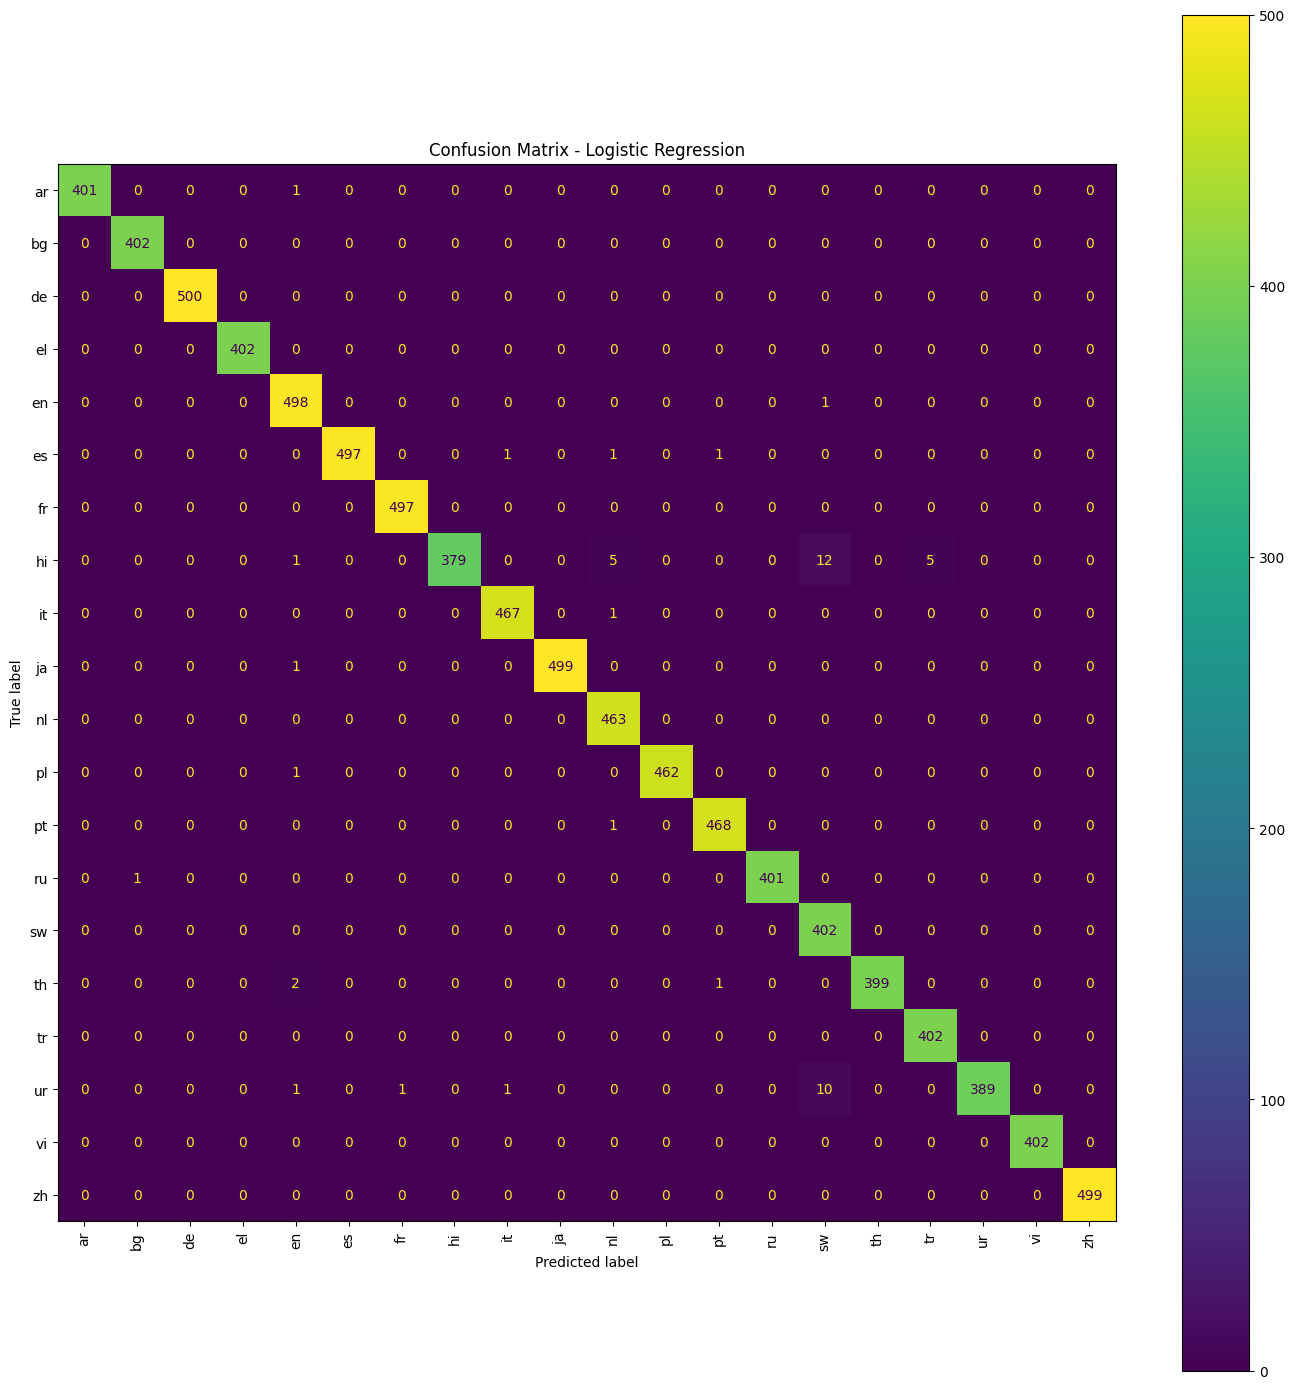

In [16]:
labels = sorted(y_val.unique())

fig, ax = plt.subplots(
    figsize=(14, 14)
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    labels=labels,
    display_labels=labels,
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.tight_layout()
plt.show()

In [17]:
wrong_predictions = val_df.copy()

wrong_predictions["predicted"] = y_val_pred

wrong_predictions = wrong_predictions[
    wrong_predictions["labels"]
    != wrong_predictions["predicted"]
]

print(
    "Số mẫu dự đoán sai:",
    len(wrong_predictions)
)

wrong_predictions[
    [
        "labels",
        "predicted",
        "clean_text"
    ]
].head(20)

Số mẫu dự đoán sai: 49


,labels,predicted,clean_text
119,ar,en,Umeda marks the northern end of the business a...
138,ja,en,13インチ Core i5 8G 480GB Microsoft office付き 1.2K...
484,es,it,No sincronizan con mi Canon
517,ur,fr,State ko techinal functions outsource karne ka...
576,th,pt,ดูที่ทาง Passeig de Gracia จนจรดตะวันออก โดยเฉ...
679,en,sw,It was kinda a slow movie
720,pt,nl,A actriz 'Desperate Housewives' Kathryn Jooste...
760,hi,tr,nahi. Blood ne uske telescope ko band kar diya.
1029,hi,nl,Maennerchor Society star par varshik nidhi ke ...
1097,ru,bg,"Посмотрите на Пасеч де Грасия на восток, особе..."


In [18]:
correct = (
    y_val.values == y_val_pred
).sum()

incorrect = (
    y_val.values != y_val_pred
).sum()

print("Correct:", correct)
print("Incorrect:", incorrect)
print("Total:", len(y_val))

print(
    "Accuracy check:",
    correct / len(y_val)
)

Correct: 8829
Incorrect: 49
Total: 8878
Accuracy check: 0.9944807389051589


In [19]:
os.makedirs(
    "../outputs/results",
    exist_ok=True
)

lr_results = pd.DataFrame({
    "model": [
        "Logistic Regression"
    ],
    "accuracy": [
        accuracy
    ],
    "precision_macro": [
        precision_macro
    ],
    "recall_macro": [
        recall_macro
    ],
    "f1_macro": [
        f1_macro
    ],
    "precision_weighted": [
        precision_weighted
    ],
    "recall_weighted": [
        recall_weighted
    ],
    "f1_weighted": [
        f1_weighted
    ]
})

lr_results

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Logistic Regression,0.994481,0.994487,0.994079,0.994181,0.994654,0.994481,0.994474


In [20]:
lr_results.to_csv(
    "../outputs/results/experiment_2_logistic_regression.csv",
    index=False
)

print("Experiment 2 results saved!")

Experiment 2 results saved!


In [21]:
joblib.dump(
    lr_model,
    "../models/logistic_regression_model.joblib"
)

print("Logistic Regression model saved!")

Logistic Regression model saved!


In [22]:
loaded_lr_model = joblib.load(
    "../models/logistic_regression_model.joblib"
)

print("Model loaded!")

Model loaded!


In [23]:
sample_text = [
    "Bonjour, comment allez-vous?"
]

sample_vector = tfidf_vectorizer.transform(
    sample_text
)

prediction = loaded_lr_model.predict(
    sample_vector
)

print(
    "Predicted language:",
    prediction[0]
)

Predicted language: fr


In [24]:
samples = [
    "Hello, how are you today?",
    "Bonjour, comment allez-vous?",
    "Xin chào, hôm nay bạn khỏe không?",
    "¿Cómo estás hoy?",
    "これは日本語の文章です。",
    "这是一个中文句子。"
]

sample_vectors = tfidf_vectorizer.transform(
    samples
)

predictions = loaded_lr_model.predict(
    sample_vectors
)

for text, language in zip(
    samples,
    predictions
):
    print(
        f"{language:>3} | {text}"
    )

 en | Hello, how are you today?
 fr | Bonjour, comment allez-vous?
 vi | Xin chào, hôm nay bạn khỏe không?
 pt | ¿Cómo estás hoy?
 ja | これは日本語の文章です。
 zh | 这是一个中文句子。


## Kết luận

- Logistic Regression được sử dụng làm mô hình thử nghiệm thứ hai cho bài toán nhận diện ngôn ngữ văn bản.
- Mô hình sử dụng cùng bộ đặc trưng TF-IDF kết hợp Character N-gram với thử nghiệm Multinomial Naive Bayes nhằm đảm bảo việc so sánh được thực hiện công bằng.
- Mô hình được huấn luyện trên tập train và đánh giá trên tập validation.
- Các chỉ số Accuracy, Precision, Recall và F1-score được sử dụng để đánh giá hiệu suất tổng thể của mô hình.
- Classification Report và Confusion Matrix được sử dụng để phân tích khả năng nhận diện của mô hình đối với từng ngôn ngữ.
- Các trường hợp dự đoán sai được kiểm tra để xác định các ngôn ngữ hoặc dạng văn bản mà mô hình còn gặp khó khăn.
- Kết quả của thử nghiệm được lưu lại để so sánh với Multinomial Naive Bayes và Linear SVM.
- Tập test tiếp tục được giữ riêng và chưa được sử dụng trong quá trình lựa chọn mô hình.